## House Price Prediction using Machine Learning in Python
Predicting house prices is a key challenge in the real estate industry, helping buyers, sellers and investors make informed decisions. By using machine learning algorithms, we can estimate the price of a house based on various features such as location, size, number of bedrooms and other relevant factors.

## Step 1: Importing Libraries and Dataset
In the first step we load the libraries which is needed for Prediction:

* Import Pandas to load the Dataframe
* Import Matplotlib to visualize the data features
* Import Seaborn to see the correlation between features using heatmap

In [2]:
# importing our libraries 
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 
import warnings 
warnings.filterwarnings("ignore")

In [3]:
# acessing the dataset 
data=pd.read_excel(r"D:\Downloads\HousePricePrediction.xlsx")
df=pd.DataFrame(data)
print(df) #.to_string() it ie used to display the full content of our dataset 

        Id  MSSubClass MSZoning  ...  BsmtFinSF2 TotalBsmtSF SalePrice
0        0          60       RL  ...         0.0       856.0  208500.0
1        1          20       RL  ...         0.0      1262.0  181500.0
2        2          60       RL  ...         0.0       920.0  223500.0
3        3          70       RL  ...         0.0       756.0  140000.0
4        4          60       RL  ...         0.0      1145.0  250000.0
...    ...         ...      ...  ...         ...         ...       ...
2914  2914         160       RM  ...         0.0       546.0       NaN
2915  2915         160       RM  ...         0.0       546.0       NaN
2916  2916          20       RL  ...         0.0      1224.0       NaN
2917  2917          85       RL  ...         0.0       912.0       NaN
2918  2918          60       RL  ...         0.0       996.0       NaN

[2919 rows x 13 columns]


## Understanding the dataset 

In [4]:
print(df.head()) #it used to print the first five rows 

   Id  MSSubClass MSZoning  ...  BsmtFinSF2 TotalBsmtSF SalePrice
0   0          60       RL  ...         0.0       856.0  208500.0
1   1          20       RL  ...         0.0      1262.0  181500.0
2   2          60       RL  ...         0.0       920.0  223500.0
3   3          70       RL  ...         0.0       756.0  140000.0
4   4          60       RL  ...         0.0      1145.0  250000.0

[5 rows x 13 columns]


In [5]:
print(df.tail()) # it is used to print the last five rows 

        Id  MSSubClass MSZoning  ...  BsmtFinSF2 TotalBsmtSF SalePrice
2914  2914         160       RM  ...         0.0       546.0       NaN
2915  2915         160       RM  ...         0.0       546.0       NaN
2916  2916          20       RL  ...         0.0      1224.0       NaN
2917  2917          85       RL  ...         0.0       912.0       NaN
2918  2918          60       RL  ...         0.0       996.0       NaN

[5 rows x 13 columns]


In [6]:
print(df.shape) # it is used to see the shape of the dataset in our dataset we have 2919 rows and 13 columns

(2919, 13)


In [7]:
print(df.columns) # it is used to see the all columns heading in our dataset 

Index(['Id', 'MSSubClass', 'MSZoning', 'LotArea', 'LotConfig', 'BldgType',
       'OverallCond', 'YearBuilt', 'YearRemodAdd', 'Exterior1st', 'BsmtFinSF2',
       'TotalBsmtSF', 'SalePrice'],
      dtype='object')


In [8]:
print(df.describe()) # it gives the mathametical calculation to the numerical columns in our dataset 

                Id   MSSubClass  ...  TotalBsmtSF      SalePrice
count  2919.000000  2919.000000  ...  2918.000000    1460.000000
mean   1459.000000    57.137718  ...  1051.777587  180921.195890
std     842.787043    42.517628  ...   440.766258   79442.502883
min       0.000000    20.000000  ...     0.000000   34900.000000
25%     729.500000    20.000000  ...   793.000000  129975.000000
50%    1459.000000    50.000000  ...   989.500000  163000.000000
75%    2188.500000    70.000000  ...  1302.000000  214000.000000
max    2918.000000   190.000000  ...  6110.000000  755000.000000

[8 rows x 9 columns]


In [9]:
print(df.info()) # it gives the all information about our dataset  

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2919 entries, 0 to 2918
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Id            2919 non-null   int64  
 1   MSSubClass    2919 non-null   int64  
 2   MSZoning      2915 non-null   object 
 3   LotArea       2919 non-null   int64  
 4   LotConfig     2919 non-null   object 
 5   BldgType      2919 non-null   object 
 6   OverallCond   2919 non-null   int64  
 7   YearBuilt     2919 non-null   int64  
 8   YearRemodAdd  2919 non-null   int64  
 9   Exterior1st   2918 non-null   object 
 10  BsmtFinSF2    2918 non-null   float64
 11  TotalBsmtSF   2918 non-null   float64
 12  SalePrice     1460 non-null   float64
dtypes: float64(3), int64(6), object(4)
memory usage: 296.6+ KB
None


In [10]:
print(df.size) # it give the size of the dataset 

37947


In [11]:
print(df.index) # it give the indexing of our dataset 

RangeIndex(start=0, stop=2919, step=1)


In [12]:
print(df.dtypes) # it give the datatype of our each column 

Id                int64
MSSubClass        int64
MSZoning         object
LotArea           int64
LotConfig        object
BldgType         object
OverallCond       int64
YearBuilt         int64
YearRemodAdd      int64
Exterior1st      object
BsmtFinSF2      float64
TotalBsmtSF     float64
SalePrice       float64
dtype: object


In [13]:
print(df.nunique()) # it give the nunquie of our data set

Id              2919
MSSubClass        16
MSZoning           5
LotArea         1951
LotConfig          5
BldgType           5
OverallCond        9
YearBuilt        118
YearRemodAdd      61
Exterior1st       15
BsmtFinSF2       272
TotalBsmtSF     1058
SalePrice        663
dtype: int64


In [14]:
print(df.head())

   Id  MSSubClass MSZoning  ...  BsmtFinSF2 TotalBsmtSF SalePrice
0   0          60       RL  ...         0.0       856.0  208500.0
1   1          20       RL  ...         0.0      1262.0  181500.0
2   2          60       RL  ...         0.0       920.0  223500.0
3   3          70       RL  ...         0.0       756.0  140000.0
4   4          60       RL  ...         0.0      1145.0  250000.0

[5 rows x 13 columns]


In [15]:
print(df.loc[df["MSSubClass"]==60,["Id","LotArea"]]) # filtering data with using condition 

        Id  LotArea
0        0     8450
2        2    11250
4        4    14260
7        7    10382
11      11    11924
...    ...      ...
2856  2856     8400
2861  2861     7162
2863  2863    11060
2885  2885    15600
2918  2918     9627

[575 rows x 2 columns]


In [16]:
print(df.loc[0:10,"Exterior1st"].count())

11


## Step 2: Data Preprocessing
Here we categorize the features based on their data types (integer, float, or object) and count the number of features in each category.

In [17]:
numerical_columns=df.select_dtypes(include=["int64"]).columns
print(numerical_columns)

Index(['Id', 'MSSubClass', 'LotArea', 'OverallCond', 'YearBuilt',
       'YearRemodAdd'],
      dtype='object')


In [18]:
categorical_columns=df.select_dtypes(include=["object"]).columns
print(categorical_columns)

Index(['MSZoning', 'LotConfig', 'BldgType', 'Exterior1st'], dtype='object')


In [19]:
fl_cols=df.select_dtypes(include=["float64"]).columns
print(fl_cols)


Index(['BsmtFinSF2', 'TotalBsmtSF', 'SalePrice'], dtype='object')


In [20]:
print(df.loc[:,"TotalBsmtSF"])

0        856.0
1       1262.0
2        920.0
3        756.0
4       1145.0
         ...  
2914     546.0
2915     546.0
2916    1224.0
2917     912.0
2918     996.0
Name: TotalBsmtSF, Length: 2919, dtype: float64


In [21]:
df.dtypes

Id                int64
MSSubClass        int64
MSZoning         object
LotArea           int64
LotConfig        object
BldgType         object
OverallCond       int64
YearBuilt         int64
YearRemodAdd      int64
Exterior1st      object
BsmtFinSF2      float64
TotalBsmtSF     float64
SalePrice       float64
dtype: object

## Step 3: Exploratory Data Analysis
Exploratory Data Analysis involves examining the dataset in depth to uncover patterns, detect anomalies and understand the underlying structure. Before drawing any conclusions, it’s important to analyze all variables carefully.
* Here we will create a heatmap using the Seaborn library to visualize correlations between features.

Heatmap saved as correlation_heatmap.png


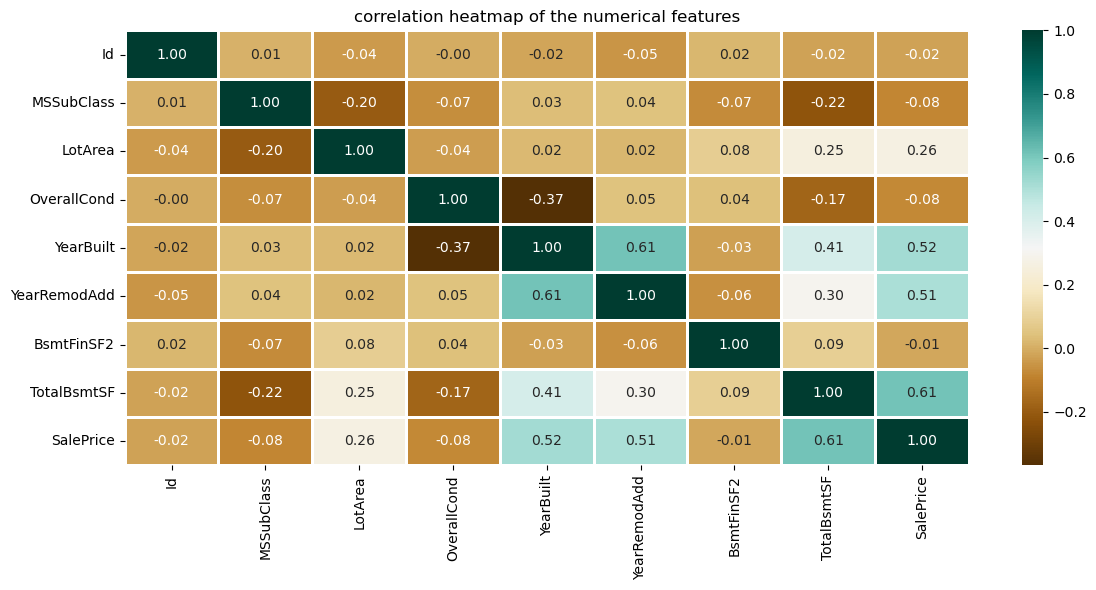

In [22]:
numerical_columns=df.select_dtypes(include=["int64","float64"])
plt.figure(figsize=(12,6))
sns.heatmap(numerical_columns.corr(),cmap="BrBG",
            fmt=".2f",linewidths=2,annot=True)
plt.title("correlation heatmap of the numerical features")
plt.tight_layout()
plt.savefig("correlation_heatmap.png")
print("Heatmap saved as correlation_heatmap.png")

<Axes: title={'center': 'No.unique values of categorical features'}, xlabel='None'>

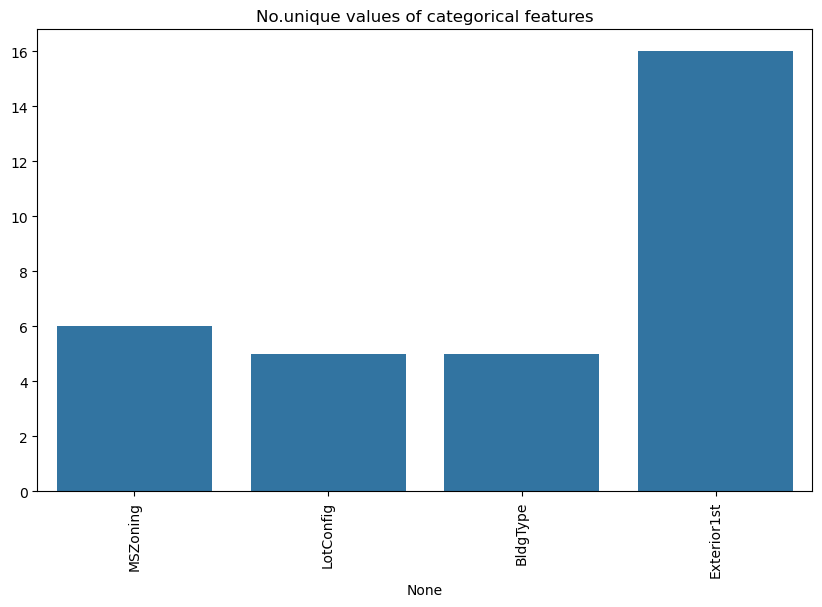

In [23]:
#To examine the categorical features, we will create a bar plot to visualize their distributions
unique_values=[]
for col in categorical_columns:
    unique_values.append(df[col].unique().size)
plt.figure(figsize=(10,6))
plt.title("No.unique values of categorical features")
plt.xticks(rotation=90)
sns.barplot(x=categorical_columns,y=unique_values)

The plot shows that Exterior1st has around 16 unique categories and other features have around  6 unique categories. To findout the actual count of each category we can plot the bargraph of each four features separately.

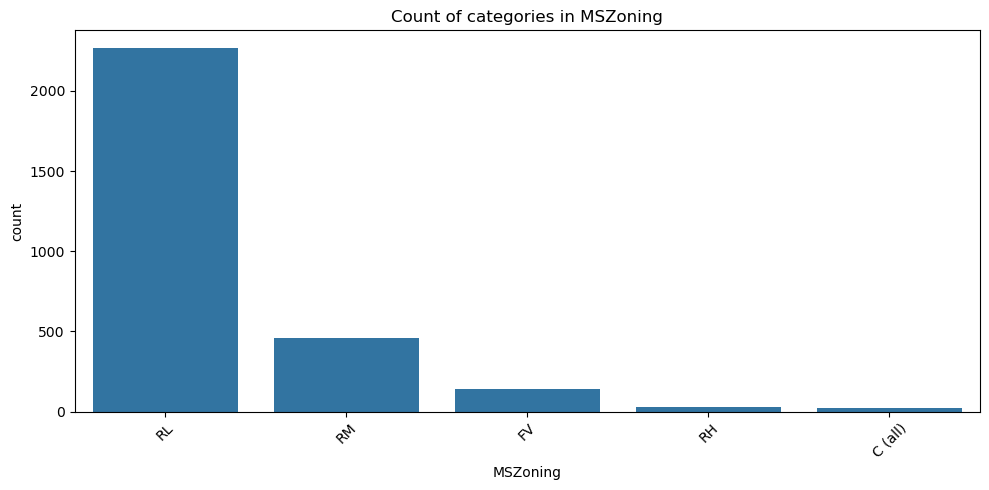

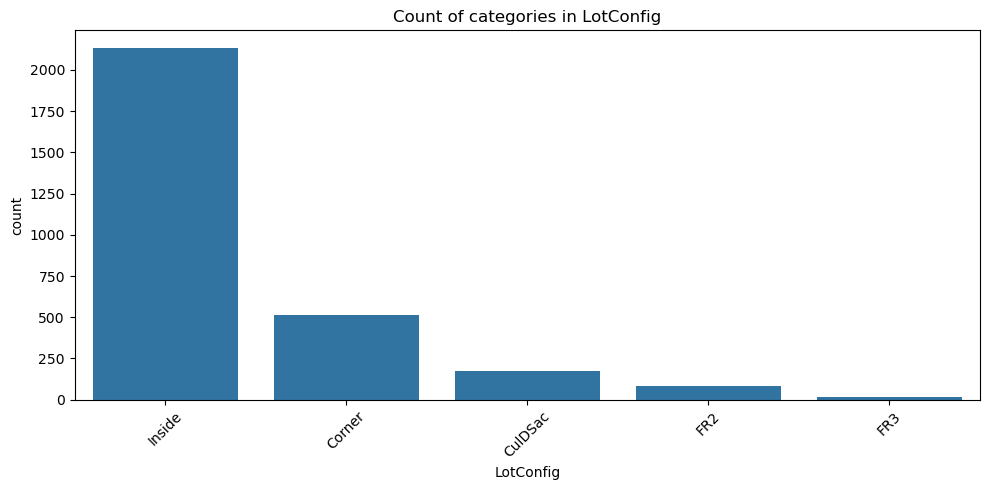

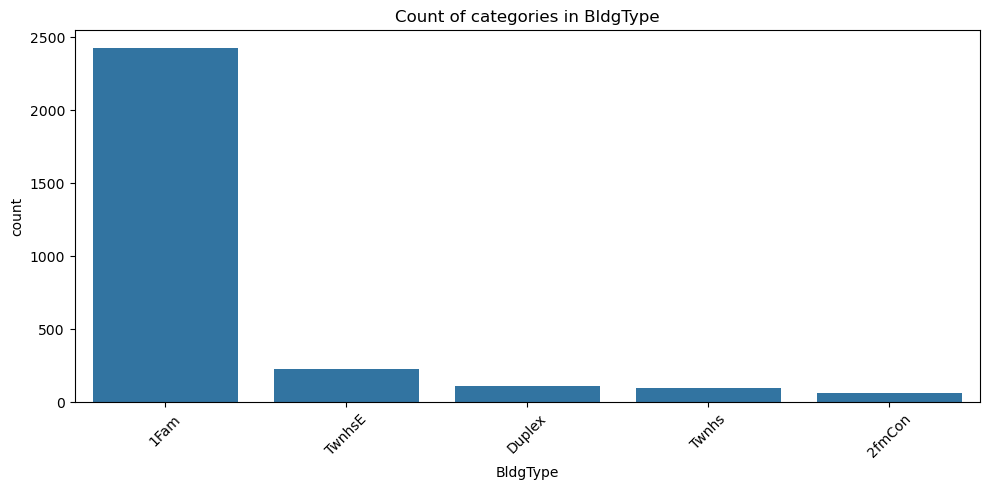

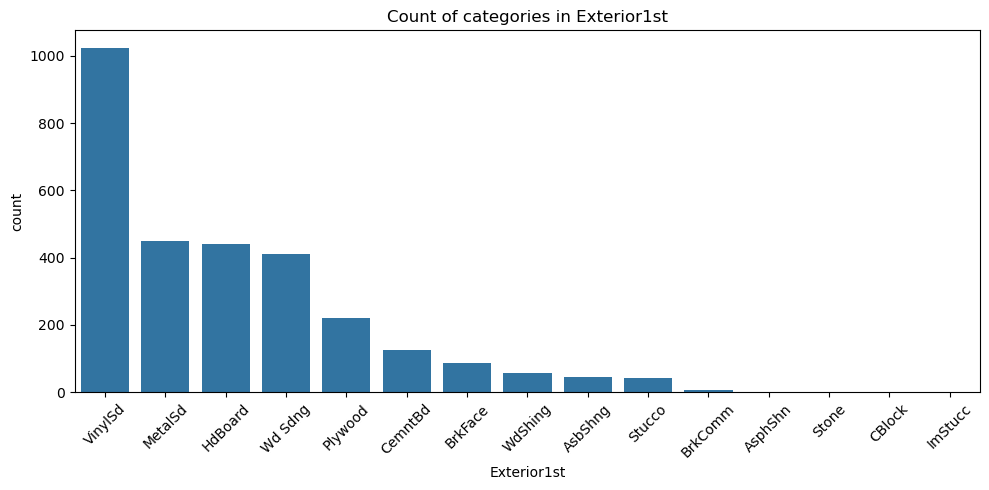

In [24]:
# Plot the category counts for each categorical feature separately
for col in categorical_columns[:4]:  # first 4 categorical columns
    plt.figure(figsize=(10, 5))
    sns.countplot(data=df, x=col, order=df[col].value_counts().index)
    plt.title(f"Count of categories in {col}")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

## Step 4: Data Cleaning
Data Cleaning is the way to improvise the data or remove incorrect, corrupted or irrelevant data. As in our dataset there are some columns that are not important and irrelevant for the model training. So we can drop that column before training. There are 2 approaches to dealing with empty/null values

* We can easily delete the column/row (if the feature or record is not much important).
* Filling the empty slots with mean/mode/0/NA/etc. (depending on the dataset requirement).

In [25]:
#As Id Column will not be participating in any prediction. So we can Drop it.
df.drop(["Id"],axis=1)

,MSSubClass,MSZoning,LotArea,LotConfig,BldgType,OverallCond,YearBuilt,YearRemodAdd,Exterior1st,BsmtFinSF2,TotalBsmtSF,SalePrice
0,60,RL,8450,Inside,1Fam,5,2003,2003,VinylSd,0.0,856.0,208500.0
1,20,RL,9600,FR2,1Fam,8,1976,1976,MetalSd,0.0,1262.0,181500.0
2,60,RL,11250,Inside,1Fam,5,2001,2002,VinylSd,0.0,920.0,223500.0
3,70,RL,9550,Corner,1Fam,5,1915,1970,Wd Sdng,0.0,756.0,140000.0
4,60,RL,14260,FR2,1Fam,5,2000,2000,VinylSd,0.0,1145.0,250000.0
...,...,...,...,...,...,...,...,...,...,...,...,...
2914,160,RM,1936,Inside,Twnhs,7,1970,1970,CemntBd,0.0,546.0,NaN
2915,160,RM,1894,Inside,TwnhsE,5,1970,1970,CemntBd,0.0,546.0,NaN
2916,20,RL,20000,Inside,1Fam,7,1960,1996,VinylSd,0.0,1224.0,NaN
2917,85,RL,10441,Inside,1Fam,5,1992,1992,HdBoard,0.0,912.0,NaN


In [26]:
#Replacing SalePrice empty values with their mean values to make the data distribution symmetric.
df["SalePrice"]=df["SalePrice"].fillna(df["SalePrice"].mean())

In [27]:
#Drop records with null values (as the empty records are very less).
New_dataset=df.dropna()

In [28]:
#Checking features which have null values in the new dataframe (if there are still any).
New_dataset.isnull().sum()

Id              0
MSSubClass      0
MSZoning        0
LotArea         0
LotConfig       0
BldgType        0
OverallCond     0
YearBuilt       0
YearRemodAdd    0
Exterior1st     0
BsmtFinSF2      0
TotalBsmtSF     0
SalePrice       0
dtype: int64

In [29]:
#Step 5: OneHotEncoder - For Label categorical features
#One hot Encoding is the best way to convert categorical data into binary vectors. This maps the values to integer values. By using OneHotEncoder, we can easily convert object data into int. So for that firstly we have to collect all the features which have the object datatype. To do so, we will make a loop.

In [30]:
from sklearn.preprocessing import OneHotEncoder

s = (New_dataset.dtypes == 'object')
object_cols = list(s[s].index)
print("Categorical variables:")
print(object_cols)
print('No. of. categorical features: ', 
      len(object_cols))

Categorical variables:
['MSZoning', 'LotConfig', 'BldgType', 'Exterior1st']
No. of. categorical features:  4


* One hot Encoding is the best way to convert categorical data into binary vectors. This maps the values to integer values. By using OneHotEncoder, we can easily convert object data into int. So for that firstly we have to collect all the features which have the object datatype. To do so, we will make a loop.

In [31]:
OH_encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
OH_cols = pd.DataFrame(OH_encoder.fit_transform(New_dataset[object_cols]))
OH_cols.index = New_dataset.index
OH_cols.columns = OH_encoder.get_feature_names_out()
df_final = New_dataset.drop(object_cols, axis=1)
df_final = pd.concat([df_final, OH_cols], axis=1)

## Step 6: Splitting Dataset into Training and Testing
X and Y splitting (i.e. Y is the SalePrice column and the rest of the other columns are X)

In [32]:
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import train_test_split
x=df_final.drop(['SalePrice'],axis=1)
y=df_final['SalePrice']
X_train,X_valid,Y_train,Y_valid=train_test_split(x,y,train_size=0.8,test_size=0.2,random_state=0)

Step 7: Model Training and Accuracy
As we have to train the model to determine the continuous values, so we will be using these regression models.

* SVM-Support Vector Machine
* Random Forest Regressor
* Linear Regressor

## 1. SVM - Support vector Machine
Support vector Machine is a supervised machine learning algorithm primarily used for classification tasks though it can also be used for regression. It works by finding the hyperplane that best divides a dataset into classes. The goal is to maximize the margin between the data points and the hyperplane.

In [33]:
from sklearn import svm
from sklearn.svm import SVC
from sklearn.metrics import mean_absolute_percentage_error

model_SVR = svm.SVR()
model_SVR.fit(X_train,Y_train)
Y_pred = model_SVR.predict(X_valid)

print(mean_absolute_percentage_error(Y_valid, Y_pred))

0.18704778826125987


##  Random Forest Regression
* Random Forest is an ensemble learning algorithm used for both classification and regression tasks. It constructs multiple decision trees during training where each tree in the forest is built on a random subset of the data and features, ensuring diversity in the model. The final output is determined by averaging the outputs of individual trees (for regression) or by majority voting (for classification).

In [34]:
from sklearn.ensemble import RandomForestRegressor

model_RFR = RandomForestRegressor(n_estimators=10)
model_RFR.fit(X_train, Y_train)
Y_pred = model_RFR.predict(X_valid)

mean_absolute_percentage_error(Y_valid, Y_pred)

0.08185102774068229

## 3. Linear Regression
Linear Regression is a statistical method used for modeling the relationship between a dependent variable and one or more independent variables. The goal is to find the line that best fits the data. This is done by minimizing the sum of the squared differences between the observed and predicted values. Linear regression assumes that the relationship between variables is linear.

In [35]:
from sklearn.linear_model import LinearRegression

model_LR = LinearRegression()
model_LR.fit(X_train, Y_train)
Y_pred = model_LR.predict(X_valid)

print(mean_absolute_percentage_error(Y_valid, Y_pred))

0.18633155158087386


Clearly SVM model is giving better accuracy as the mean absolute error is the least among all the other regressor models i.e. 0.18 approx. To get much better results ensemble learning techniques like Bagging and Boosting can also be used.